In [3]:
from torch import nn
import torch
from torchinfo import summary
from torchvision import transforms
import torch.nn as nn
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import random
from torch.utils.data import dataloader
from collections import OrderedDict

# read_data

In [4]:
def get_data():

    train_data = datasets.MNIST(
        root="image",
        train=True,
        download=True,
        transform=ToTensor()
    )

    test_data = datasets.MNIST(
        root="image",
        train=False,
        download=True,
        transform=ToTensor()
    )

    return train_data, test_data

In [5]:
train_data, test_data = get_data()
print(f"Number of training samples: {len(train_data)}")
print(f"Number of test samples: {len(test_data)}")


random_index = random.randint(0, len(train_data)-1  ) #取得隨機索引
img , label = train_data[random_index] #根據隨機索引取得圖像和標籤
class_names = train_data.classes #取得類別名稱列表

print(f"image shape: {img.shape}    label: {label}") #顯示圖像形狀和標籤


Number of training samples: 60000
Number of test samples: 10000
image shape: torch.Size([1, 28, 28])    label: 6


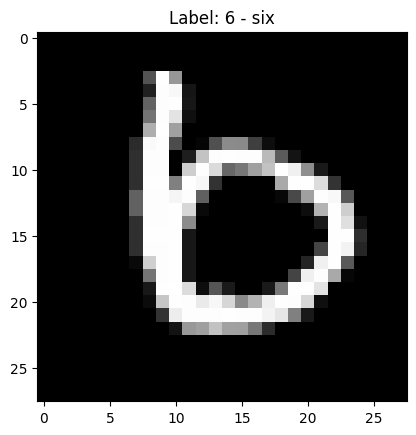

In [6]:
plt.imshow(img.permute(1, 2, 0), cmap="gray") #顯示圖像
plt.title(f"Label: {class_names[label]}") #顯示標籤名稱
plt.show() 

In [7]:
def create_data_loaders(train_data, test_data, batch_size):
    train_loader = dataloader.DataLoader(
        train_data, 
        batch_size=batch_size, 
        shuffle=True
        ) 
    #建立訓練資料的DataLoader，設定批次大小為32並打亂資料順序
    #shuffle=True 代表每次取資料時會打亂順序，有助於提升模型的泛化能力，避免同類型資料集中在一起
    
    test_loader = dataloader.DataLoader(
        test_data, 
        batch_size=batch_size, 
        shuffle=False
        ) 
    #建立測試資料的DataLoader，設定批次大小為32不打亂資料順序
    #shuffle=False 代表每次取資料時不打亂順序，確保測試結果
    return train_loader, test_loader

In [8]:
batch_size = 32
train_loader, test_loader = create_data_loaders(train_data, test_data, batch_size)
x_first_batch, y_first_batch = next(iter(train_loader))


# Model

In [9]:
class ImageModel(nn.Module):
    def __init__(self,in_features,out_features):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(
                in_channels=in_features, 
                out_channels=4, 
                kernel_size=(3,3), 
                stride=2, 
                padding=1
                ),
            nn.ReLU(),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(
                in_channels=4, 
                out_channels=4, 
                kernel_size=(3,3), 
                stride=1, 
                padding=0
                ),
            nn.ReLU(),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(
                in_channels=4, 
                out_channels=12, 
                kernel_size=(3,3), 
                stride=1, 
                padding=0
                ),
            nn.ReLU(),
        )
       
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return x

In [10]:
class PatchEmbed(nn.Module):
    """
    2D Image to Patch Embedding 
    把一張 2D 圖片 Image (H × W × C)---> Transformer 可以處理的 Token sequence (N × D)。
    N = patch數量
    D = embedding dimension 
    """
    def __init__(self, img_size=10, patch_size=2, in_c=12, embed_dim=32, norm_layer=None):
        super().__init__()
        img_size = (img_size, img_size) # (H, W) (10, 10)
        patch_size = (patch_size, patch_size) # (H, W) (2, 2)
        self.img_size = img_size # (H, W) (10, 10)
        self.patch_size = patch_size # (H, W) (2, 2)
        self.grid_size = (img_size[0] // patch_size[0], img_size[1] // patch_size[1]) # (H, W) (10//2, 10//2) = (5, 5)
        self.num_patches = self.grid_size[0] * self.grid_size[1] # (H, W) (5*5) = 25

        self.proj = nn.Conv2d(in_c, embed_dim, kernel_size=patch_size, stride=patch_size) # (12, 32, kernel_size=(4, 4), stride=(4, 4))
        self.norm = norm_layer(embed_dim) if norm_layer else nn.Identity() # (32, 32) or Identity()

    def forward(self, x):
        B, C, H, W = x.shape # (1, 12, 10, 10)
        # flatten: [B, C, H, W] -> [B, C, HW]
        # transpose: [B, C, HW] -> [B, HW, C]
        x = self.proj(x).flatten(2).transpose(1, 2)
        x = self.norm(x) # (B, num_patches, embed_dim) = (B, 25, 32)
        return x

In [11]:
class Attention(nn.Module):
    def __init__(self,
                 dim,   # 输入token的dim
                 num_heads,
                 qkv_bias=False,
                 qk_scale=None,
                 attn_drop_ratio=0.,
                 proj_drop_ratio=0.):
        super(Attention, self).__init__()
        self.num_heads = num_heads # 注意力头的数量 2   
        head_dim = dim // num_heads # 每个注意力头的维度 32//2=16
        self.scale = qk_scale or head_dim ** -0.5 # 缩放因子，默认为 head_dim 的负平方根 1/sqrt(16)=0.25
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias) 
        # Linear layrer，将输入的 token embedding 映射到（Q）、（K）和（V），输出维度是输入维度的三倍 qkv=xW+b  
        # Q K V 的值 = token feature × 訓練好的權重
        self.attn_drop = nn.Dropout(attn_drop_ratio) 
        self.proj = nn.Linear(dim, dim) # 线性层，用于将多头注意力的输出映射回输入维度 proj=xW+b
        self.proj_drop = nn.Dropout(proj_drop_ratio)

    def forward(self, x):
        # [batch_size, num_patches + 1, total_embed_dim]
        B, N, C = x.shape

        # qkv(): -> [batch_size, num_patches + 1, 3 * total_embed_dim]
        # reshape: -> [batch_size, num_patches + 1, 3, num_heads, embed_dim_per_head]
        # permute: -> [3, batch_size, num_heads, num_patches + 1, embed_dim_per_head]
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)

        # print("qkv shape :", qkv.shape)
        # [batch_size, num_heads, num_patches + 1, embed_dim_per_head]
        q, k, v = qkv[0], qkv[1], qkv[2]  # make torchscript happy (cannot use tensor as tuple)

        # print("q shape:", q.shape)
        # print("k shape:", k.shape)
        # print("v shape:", v.shape)

        # transpose: -> [batch_size, num_heads, embed_dim_per_head, num_patches + 1]
        # @: multiply -> [batch_size, num_heads, num_patches + 1, num_patches + 1]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        # @: multiply -> [batch_size, num_heads, num_patches + 1, embed_dim_per_head]
        # transpose: -> [batch_size, num_patches + 1, num_heads, embed_dim_per_head]
        # reshape: -> [batch_size, num_patches + 1, total_embed_dim]
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)

        return x

In [12]:
class Mlp(nn.Module):
    """
    MLP as used in Vision Transformer, MLP-Mixer and related networks
    """
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

In [13]:
class Block(nn.Module):
    def __init__(self,
                 dim=32,
                 num_heads=4,
                 mlp_ratio=2.0,
                 qkv_bias=True,
                 qk_scale=None,
                 drop_ratio=0.,
                 attn_drop_ratio=0.,
                 act_layer=nn.GELU,
                 norm_layer=nn.LayerNorm):
        super().__init__()

        self.norm1 = norm_layer(dim)
        self.attn = Attention(
            dim=dim,
            num_heads=num_heads,
            qkv_bias=qkv_bias,
            qk_scale=qk_scale,
            attn_drop_ratio=attn_drop_ratio,
            proj_drop_ratio=drop_ratio
        )

        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(
            in_features=dim,
            hidden_features=mlp_hidden_dim,
            act_layer=act_layer,
            drop=drop_ratio
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

In [14]:
class HybridVisionTransformer(nn.Module):
    def __init__(self,
                 num_classes=10,
                 embed_dim=32,
                 depth=2,
                 num_heads=4,
                 mlp_ratio=2.0,
                 qkv_bias=True,
                 qk_scale=None,
                 drop_ratio=0.,
                 attn_drop_ratio=0.,
                 representation_size=None,
                 norm_layer=None,
                 act_layer=None):
        super().__init__()

        norm_layer = norm_layer or nn.LayerNorm
        act_layer = act_layer or nn.GELU

        # CNN backbone: [B,1,28,28] -> [B,12,10,10]
        self.cnn = ImageModel(
            in_features=1, 
            out_features=12
        )

        # Patch embedding: [B,12,10,10] -> [B,25,32]
        self.patch_embed = PatchEmbed(
            img_size=10,
            patch_size=2,
            in_c=12,
            embed_dim=embed_dim,
            norm_layer=norm_layer
        )
        num_patches = self.patch_embed.num_patches  # 25

        # cls token + pos embedding
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(p=drop_ratio)

        # transformer blocks
        self.blocks = nn.Sequential(*[
            Block(
                dim=embed_dim,
                num_heads=num_heads,
                mlp_ratio=mlp_ratio,
                qkv_bias=qkv_bias,
                qk_scale=qk_scale,
                drop_ratio=drop_ratio,
                attn_drop_ratio=attn_drop_ratio,
                norm_layer=norm_layer,
                act_layer=act_layer
            )
            for _ in range(depth)
        ])

        self.norm = norm_layer(embed_dim)

        # pre_logits
        if representation_size is not None:
            self.has_logits = True
            self.num_features = representation_size
            self.pre_logits = nn.Sequential(OrderedDict([
                ("fc", nn.Linear(embed_dim, representation_size)),
                ("act", nn.Tanh())
            ]))
        else:
            self.has_logits = False
            self.num_features = embed_dim
            self.pre_logits = nn.Identity()

        # classifier
        self.head = nn.Linear(self.num_features, num_classes)

        # init
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward_features(self, x):
        x = self.cnn(x)                 # [B,12,10,10]
        x = self.patch_embed(x)         # [B,25,32]

        cls_token = self.cls_token.expand(x.shape[0], -1, -1)  # [B,1,32]
        x = torch.cat((cls_token, x), dim=1)                   # [B,26,32]

        x = self.pos_drop(x + self.pos_embed)                  # [B,26,32]
        x = self.blocks(x)                                     # [B,26,32]
        x = self.norm(x)                                       # [B,26,32]

        x = self.pre_logits(x[:, 0])                           # [B,32] or [B,representation_size]
        return x

    def forward(self, x):
        x = self.forward_features(x)
        x = self.head(x)
        return x

In [15]:
def vit_mnist_hybrid(num_classes=10):
    model = HybridVisionTransformer(
        num_classes=num_classes,
        embed_dim=32,
        depth=1,
        num_heads=4,
        mlp_ratio=2.0,
        qkv_bias=True,
        representation_size=None
    )
    return model

In [16]:
model = vit_mnist_hybrid(num_classes=10)

x = torch.randn(1, 1, 28, 28)
y = model(x)

print(y.shape)   # torch.Size([1, 10])

torch.Size([1, 10])


In [17]:
summary(
    model,
    input_size=(1, 1, 28, 28),
    depth=5,
    col_names=("input_size","output_size","num_params","kernel_size","mult_adds","trainable"),
    row_settings=("depth","var_names")
)

Layer (type (var_name):depth-idx)                  Input Shape               Output Shape              Param #                   Kernel Shape              Mult-Adds                 Trainable
HybridVisionTransformer (HybridVisionTransformer)  [1, 1, 28, 28]            [1, 10]                   864                       --                        --                        True
├─ImageModel (cnn): 1-1                            [1, 1, 28, 28]            [1, 12, 10, 10]           --                        --                        --                        True
│    └─Sequential (block1): 2-1                    [1, 1, 28, 28]            [1, 4, 14, 14]            --                        --                        --                        True
│    │    └─Conv2d (0): 3-1                        [1, 1, 28, 28]            [1, 4, 14, 14]            40                        [3, 3]                    7,840                     True
│    │    └─ReLU (1): 3-2                          [1, 4, 14, 14]

In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [19]:
def train_one_epoch(model, dataloader, loss_fn, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)

        # forward
        pred = model(X)               # [B,10]
        loss = loss_fn(pred, y)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 紀錄
        total_loss += loss.item() * X.size(0)
        total_correct += (pred.argmax(dim=1) == y).sum().item()
        total_samples += X.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc

In [20]:
@torch.no_grad()
def evaluate(model, dataloader, loss_fn, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)

        pred = model(X)
        loss = loss_fn(pred, y)

        total_loss += loss.item() * X.size(0)
        total_correct += (pred.argmax(dim=1) == y).sum().item()
        total_samples += X.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc

In [21]:
epochs = 10

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, loss_fn, device)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Test  Loss: {test_loss:.4f}, Test  Acc: {test_acc:.4f}")
    print("-" * 40)

Epoch 1/10
Train Loss: 0.6175, Train Acc: 0.7860
Test  Loss: 0.1433, Test  Acc: 0.9575
----------------------------------------
Epoch 2/10
Train Loss: 0.1285, Train Acc: 0.9603
Test  Loss: 0.0957, Test  Acc: 0.9714
----------------------------------------
Epoch 3/10
Train Loss: 0.1004, Train Acc: 0.9690
Test  Loss: 0.0887, Test  Acc: 0.9737
----------------------------------------
Epoch 4/10
Train Loss: 0.0847, Train Acc: 0.9736
Test  Loss: 0.0752, Test  Acc: 0.9763
----------------------------------------
Epoch 5/10
Train Loss: 0.0755, Train Acc: 0.9767
Test  Loss: 0.0759, Test  Acc: 0.9764
----------------------------------------
Epoch 6/10
Train Loss: 0.0699, Train Acc: 0.9782
Test  Loss: 0.0739, Test  Acc: 0.9774
----------------------------------------
Epoch 7/10
Train Loss: 0.0637, Train Acc: 0.9799
Test  Loss: 0.0598, Test  Acc: 0.9807
----------------------------------------
Epoch 8/10
Train Loss: 0.0596, Train Acc: 0.9810
Test  Loss: 0.0779, Test  Acc: 0.9771
-----------------

In [22]:
def test_accuracy(model, dataloader, device):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            outputs = model(X)                 # [B,10]
            preds = outputs.argmax(dim=1)      # [B]

            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = correct / total
    return acc

In [23]:
acc = test_accuracy(model, test_loader, device)
print(f"Test Accuracy: {acc:.4f}")

Test Accuracy: 0.9845


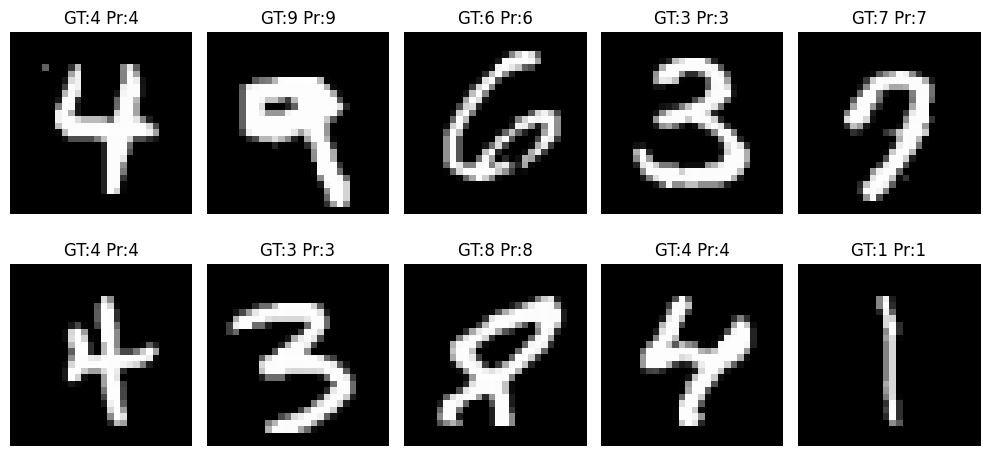

In [24]:
model.eval()

fig, axes = plt.subplots(2, 5, figsize=(10,5))

for ax in axes.flatten():
    idx = random.randint(0, len(test_data)-1)   
    img, label = test_data[idx]

    x = img.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(x)
        pred_label = pred.argmax(dim=1).item()

    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"GT:{label} Pr:{pred_label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

#  Quantization

In [25]:
import torch

class quantize(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input_, num_of_bits):
        n = 2 ** 16
        e = 1e-9
        input_ = input_.clamp(-128 + e, 128 - e)
        input_ = torch.round(input_ * n) / n
        return input_

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.clone(), None


def float_to_fixed_bin(x, frac_bits=16, total_bits=24):
    scale = 2 ** frac_bits
    fixed = int(round(float(x) * scale))

    if fixed < 0:
        fixed = (1 << total_bits) + fixed

    return format(fixed, f'0{total_bits}b')



In [26]:
x = torch.tensor([
    -5,
    5
])

# 保留量化後數值
x_q = quantize.apply(x, 16)

# 另外存 binary
x_bin = [float_to_fixed_bin(v) for v in x_q]

print("Original:")
print(x)

print("\nQuantized:")
print(x_q)

print("\nBinary:")
for b in x_bin:
    print(b)

print("\nDifference:")
print(x_q - x)

Original:
tensor([-5,  5])

Quantized:
tensor([-5.,  5.])

Binary:
111110110000000000000000
000001010000000000000000

Difference:
tensor([0., 0.])
